# SVHN 模型的 INT8 静态量化实验

## 1. 实验目的

本实验在第二次作业中训练得到的 SVHN 分类 CNN 模型基础上，完成 INT8 静态量化流程。

实验主要包括以下几个部分：

（1）加载已训练好的 FP32 模型，并测试其在 SVHN 测试集上的分类准确率、模型大小和 CPU 推理延迟；

（2）手动实现线性量化和反量化函数，加深对量化公式的理解；

（3）使用 PyTorch 的静态量化流程，对模型进行模块融合、校准和 INT8 转换；

（4）比较量化前后模型在精度、大小、推理速度和逐层输出误差方面的变化。

## 2. 实验原理

线性量化的基本思想是将连续的浮点数映射到有限范围内的整数。对于一个浮点张量，首先根据其最小值和最大值确定量化区间，再计算 scale 和 zero point。量化时将浮点数除以 scale 后加上 zero point，并四舍五入到整数；反量化时再根据 scale 和 zero point 将整数近似恢复为浮点数。

本实验手动实现了 per-tensor 非对称线性量化函数，用于验证量化和反量化过程。实际模型量化部分采用训练后静态量化方法，即 PTQ。静态量化需要先插入 QuantStub 和 DeQuantStub，用于标记模型输入量化和输出反量化的位置；然后对 Conv、BatchNorm、ReLU 以及 Linear、ReLU 等结构进行融合；再利用少量训练样本对激活值范围进行校准；最后将 FP32 模型转换为 INT8 推理模型。
  
由于本机运行时使用的量化后端为 onednn，该后端要求卷积权重采用 zero point 为 0 的对称量化。因此本实验中激活值采用 per-tensor affine 非对称量化，权重采用 per-tensor symmetric 对称量化。手写量化函数部分仍按照非对称线性量化实现。

## 3. 实验设置

本实验使用 SVHN Format 2 数据集，其中训练集包含 73257 张图像，测试集包含 26032 张图像。图像大小为 32×32，颜色通道为 RGB，分类类别为数字 0 到 9。实验模型采用第二次作业中训练得到的基础 CNN 模型，其最佳测试准确率约为 96.16%。

在量化实验中，使用训练集中的 2048 张图像作为校准数据，校准批次数为 16，batch size 为 128。所有精度和推理延迟均在 CPU 上测试。推理延迟使用单张图片重复推理多次进行测试，并取多轮测试结果的中位数作为最终延迟，以减小偶然波动对结果的影响。

## 4. 实验代码

### (1) 导入库与基本设置

In [1]:
import os
import copy
import time
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 尽量固定 CPU 线程数，使 Notebook 中的延迟测试更稳定
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from scipy.io import loadmat

from torch.ao.quantization import (
    QuantStub,
    DeQuantStub,
    QConfig,
    MinMaxObserver,
    prepare,
    convert,
    fuse_modules
)

warnings.filterwarnings("ignore", category=DeprecationWarning)

torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cpu")
print("Using device:", device)
print("PyTorch version:", torch.__version__)
print("torch num threads:", torch.get_num_threads())
print("quantized engines:", torch.backends.quantized.supported_engines)

Using device: cpu
PyTorch version: 2.10.0+cpu
torch num threads: 1
quantized engines: ['onednn']


### (2) 实验路径和参数

In [2]:
TRAIN_MAT_PATH = r".\train_32x32.mat"
TEST_MAT_PATH = r".\test_32x32.mat"
CHECKPOINT_PATH = r".\Results\bs128_lr0.001_ep100_seed42_20260415_153629\best_model.pth"

OUT_DIR = r".\Results_HW4_Notebook"
os.makedirs(OUT_DIR, exist_ok=True)

BATCH_SIZE = 128
CALIB_SIZE = 2048
MAX_CALIB_BATCHES = 16

print("Train mat:", TRAIN_MAT_PATH)
print("Test mat:", TEST_MAT_PATH)
print("Checkpoint:", CHECKPOINT_PATH)
print("Output dir:", OUT_DIR)

Train mat: .\train_32x32.mat
Test mat: .\test_32x32.mat
Checkpoint: .\Results\bs128_lr0.001_ep100_seed42_20260415_153629\best_model.pth
Output dir: .\Results_HW4_Notebook


### (3) 数据集读取与预处理
SVHN 原始 `.mat` 文件中的图像维度为 `(32, 32, 3, N)`，标签维度为 `(N, 1)`。由于标签 10 表示数字 0，因此读取数据时需要将标签 10 转换为 0，并将图像维度调整为 PyTorch 常用的 `(N, C, H, W)` 格式。本实验测试和校准阶段不使用随机数据增强，只进行 ToTensor 和 Normalize 操作。

In [3]:
class SVHNDataset(Dataset):
    def __init__(self, mat_path, transform=None, max_samples=None):
        data = loadmat(mat_path)
        images = data["X"]                      # (32, 32, 3, N)
        labels = data["y"].astype(np.int64).squeeze()

        labels[labels == 10] = 0
        images = np.transpose(images, (3, 0, 1, 2))   # (N, 32, 32, 3)

        if max_samples is not None:
            images = images[:max_samples]
            labels = labels[:max_samples]

        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = int(self.labels[idx])

        if self.transform is not None:
            image = self.transform(image)
        else:
            image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0

        return image, label


test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_dataset = SVHNDataset(TEST_MAT_PATH, transform=test_transform)
calib_dataset = SVHNDataset(TRAIN_MAT_PATH, transform=test_transform, max_samples=CALIB_SIZE)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
calib_loader = DataLoader(calib_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Test samples:", len(test_dataset))
print("Calibration samples:", len(calib_dataset))

Test samples: 26032
Calibration samples: 2048


### (4) 基础 CNN 模型

In [4]:
class QuantizedSimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.quant = QuantStub()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

        self.dequant = DeQuantStub()

    def fuse_model(self):
        fuse_modules(self.features, ["0", "1", "2"], inplace=True)
        fuse_modules(self.features, ["3", "4", "5"], inplace=True)
        fuse_modules(self.features, ["8", "9", "10"], inplace=True)
        fuse_modules(self.features, ["11", "12", "13"], inplace=True)
        fuse_modules(self.features, ["16", "17", "18"], inplace=True)
        fuse_modules(self.features, ["19", "20", "21"], inplace=True)
        fuse_modules(self.classifier, ["1", "2"], inplace=True)

    def forward(self, x):
        x = self.quant(x)
        x = self.features(x)
        x = self.classifier(x)
        x = self.dequant(x)
        return x

### (5) 加载作业2训练好的 FP32 模型

In [5]:
def load_fp32_model(checkpoint_path):
    model = QuantizedSimpleCNN(num_classes=10)

    checkpoint = torch.load(checkpoint_path, map_location="cpu")

    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        checkpoint = checkpoint["state_dict"]

    new_checkpoint = {}
    for k, v in checkpoint.items():
        if k.startswith("module."):
            k = k[len("module."):]
        new_checkpoint[k] = v

    missing, unexpected = model.load_state_dict(new_checkpoint, strict=False)
    model.eval()
    return model


fp32_model = load_fp32_model(CHECKPOINT_PATH).to(device)
print("FP32 model loaded.")

FP32 model loaded.


### (6) 手动实现线性量化和反量化
为了验证线性量化原理，先手动实现 per-tensor 非对称量化函数。这里根据张量整体的最小值和最大值计算 scale 和 zero point，再将浮点张量映射为 8 bit 整数。反量化时根据相同的 scale 和 zero point 近似恢复浮点值。

In [6]:
def linear_quantize(x, num_bits=8):
    qmin = 0
    qmax = 2 ** num_bits - 1

    x_min = x.min().item()
    x_max = x.max().item()

    if x_max == x_min:
        scale = 1.0
        zero_point = 0
        q = torch.zeros_like(x, dtype=torch.uint8)
        return q, scale, zero_point

    scale = (x_max - x_min) / (qmax - qmin)
    zero_point = qmin - round(x_min / scale)
    zero_point = max(qmin, min(qmax, zero_point))

    q = torch.round(x / scale + zero_point)
    q = torch.clamp(q, qmin, qmax).to(torch.uint8)

    return q, scale, zero_point


def linear_dequantize(q, scale, zero_point):
    return scale * (q.float() - zero_point)


x_demo = torch.tensor([-1.0, -0.5, 0.0, 0.5, 1.0])
q_demo, scale_demo, zp_demo = linear_quantize(x_demo)
x_deq_demo = linear_dequantize(q_demo, scale_demo, zp_demo)

print("Original:", x_demo)
print("Quantized:", q_demo)
print("Scale:", scale_demo)
print("Zero point:", zp_demo)
print("Dequantized:", x_deq_demo)

Original: tensor([-1.0000, -0.5000,  0.0000,  0.5000,  1.0000])
Quantized: tensor([  1,  64, 128, 192, 255], dtype=torch.uint8)
Scale: 0.00784313725490196
Zero point: 128
Dequantized: tensor([-0.9961, -0.5020,  0.0000,  0.5020,  0.9961])


### (7) 模型评估函数

In [7]:
@torch.no_grad()
def evaluate_accuracy(model, dataloader, device="cpu"):
    model.eval()
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / total

### (8) 测试 FP32 模型准确率

In [8]:
fp32_accuracy = evaluate_accuracy(fp32_model, test_loader, device)
print(f"FP32 Test Accuracy: {fp32_accuracy:.6f}")

FP32 Test Accuracy: 0.961624


### (9) 设置量化后端和 qconfig
本实验使用静态量化配置。激活值采用 per-tensor affine 量化，权重采用 per-tensor symmetric 量化。这里选择 symmetric 权重量化是因为当前 PyTorch 的 onednn 后端要求卷积权重的 zero point 必须为 0，否则模型转换时会报错。

In [9]:
supported_engines = torch.backends.quantized.supported_engines
print("Supported quantized engines:", supported_engines)

if "onednn" in supported_engines:
    torch.backends.quantized.engine = "onednn"
elif "fbgemm" in supported_engines:
    torch.backends.quantized.engine = "fbgemm"
else:
    torch.backends.quantized.engine = supported_engines[0]

print("Selected quantized engine:", torch.backends.quantized.engine)

activation_observer = MinMaxObserver.with_args(
    dtype=torch.quint8,
    qscheme=torch.per_tensor_affine
)

weight_observer = MinMaxObserver.with_args(
    dtype=torch.qint8,
    qscheme=torch.per_tensor_symmetric
)

qconfig = QConfig(
    activation=activation_observer,
    weight=weight_observer
)

qconfig

Supported quantized engines: ['onednn']
Selected quantized engine: onednn


QConfig(activation=functools.partial(<class 'torch.ao.quantization.observer.MinMaxObserver'>, dtype=torch.quint8, qscheme=torch.per_tensor_affine){}, weight=functools.partial(<class 'torch.ao.quantization.observer.MinMaxObserver'>, dtype=torch.qint8, qscheme=torch.per_tensor_symmetric){})

### (10) 模型融合、校准和 INT8 转换

In [10]:
def calibrate(model, calib_loader, max_batches=16):
    model.eval()
    with torch.no_grad():
        for batch_idx, (images, _) in enumerate(calib_loader):
            if batch_idx >= max_batches:
                break
            model(images)


def build_int8_model(fp32_model, calib_loader, qconfig, max_calib_batches=16):
    model = copy.deepcopy(fp32_model).to("cpu")
    model.eval()

    model.fuse_model()
    model.qconfig = qconfig

    prepare(model, inplace=True)

    calibrate(model, calib_loader, max_batches=max_calib_batches)

    convert(model, inplace=True)

    return model


int8_model = build_int8_model(
    fp32_model=fp32_model,
    calib_loader=calib_loader,
    qconfig=qconfig,
    max_calib_batches=MAX_CALIB_BATCHES
)

print("INT8 model is ready.")

INT8 model is ready.


### (11) 测试 INT8 模型准确率

In [11]:
int8_accuracy = evaluate_accuracy(int8_model, test_loader, device)
accuracy_loss = fp32_accuracy - int8_accuracy

print(f"FP32 Accuracy: {fp32_accuracy:.6f}")
print(f"INT8 Accuracy: {int8_accuracy:.6f}")
print(f"Accuracy Loss: {accuracy_loss:.6f}")

FP32 Accuracy: 0.961624
INT8 Accuracy: 0.961240
Accuracy Loss: 0.000384


### (12) 计算模型大小

In [12]:
def get_model_size_mb(model, path):
    torch.save(model.state_dict(), path)
    size_mb = os.path.getsize(path) / 1024 / 1024
    return size_mb


fp32_size_path = os.path.join(OUT_DIR, "fp32_model_state_dict.pth")
int8_size_path = os.path.join(OUT_DIR, "int8_model_state_dict.pth")

fp32_size_mb = get_model_size_mb(fp32_model, fp32_size_path)
int8_size_mb = get_model_size_mb(int8_model, int8_size_path)

compression_ratio = fp32_size_mb / int8_size_mb

print(f"FP32 Size: {fp32_size_mb:.4f} MB")
print(f"INT8 Size: {int8_size_mb:.4f} MB")
print(f"Compression Ratio: {compression_ratio:.4f}x")

FP32 Size: 3.1276 MB
INT8 Size: 0.7905 MB
Compression Ratio: 3.9564x


### (13) 测试 CPU 单张推理延迟

In [13]:
@torch.inference_mode()
def benchmark_latency(model, sample_input, warmup=200, repeat=20, loops=200):
    model.eval()

    # warmup
    for _ in range(warmup):
        _ = model(sample_input)

    times = []
    for _ in range(repeat):
        start = time.perf_counter()
        for _ in range(loops):
            _ = model(sample_input)
        end = time.perf_counter()

        times.append((end - start) * 1000 / loops)

    times = np.array(times)

    return {
        "mean_ms": float(times.mean()),
        "median_ms": float(np.median(times)),
        "min_ms": float(times.min()),
        "max_ms": float(times.max()),
        "std_ms": float(times.std())
    }


sample_input, _ = test_dataset[0]
sample_input = sample_input.unsqueeze(0).contiguous().to("cpu")

fp32_latency_info = benchmark_latency(fp32_model, sample_input)
int8_latency_info = benchmark_latency(int8_model, sample_input)

# 报告中使用 median 更稳定
fp32_latency_ms = fp32_latency_info["median_ms"]
int8_latency_ms = int8_latency_info["median_ms"]
speedup = fp32_latency_ms / int8_latency_ms

print("FP32 latency info:", fp32_latency_info)
print("INT8 latency info:", int8_latency_info)

print(f"FP32 Latency median: {fp32_latency_ms:.4f} ms")
print(f"INT8 Latency median: {int8_latency_ms:.4f} ms")
print(f"Speedup: {speedup:.4f}x")

FP32 latency info: {'mean_ms': 4.20099457501783, 'median_ms': 4.196765500091715, 'min_ms': 3.2546730000467505, 'max_ms': 5.163849999953527, 'std_ms': 0.6323006478705983}
INT8 latency info: {'mean_ms': 2.787059849993966, 'median_ms': 2.8033182499348186, 'min_ms': 2.1270084999559913, 'max_ms': 3.6141425000096206, 'std_ms': 0.37870301684447444}
FP32 Latency median: 4.1968 ms
INT8 Latency median: 2.8033 ms
Speedup: 1.4971x


### (14) 计算逐层输出 MSE

In [14]:
def collect_layer_outputs(model, layer_names, x):
    outputs = {}
    hooks = []

    def save_output(name):
        def hook(module, input, output):
            if isinstance(output, torch.Tensor):
                if output.is_quantized:
                    output = output.dequantize()
                outputs[name] = output.detach().cpu()
        return hook

    for name, module in model.named_modules():
        if name in layer_names:
            hooks.append(module.register_forward_hook(save_output(name)))

    model.eval()
    with torch.no_grad():
        _ = model(x)

    for h in hooks:
        h.remove()

    return outputs


def compute_layer_mse(fp32_model, int8_model, dataloader, layer_names, num_batches=8):
    fp32_ref = copy.deepcopy(fp32_model).to("cpu")
    fp32_ref.eval()
    fp32_ref.fuse_model()

    mse_sum = {name: 0.0 for name in layer_names}
    count = 0

    for batch_idx, (images, _) in enumerate(dataloader):
        if batch_idx >= num_batches:
            break

        images = images.to("cpu")

        fp32_outputs = collect_layer_outputs(fp32_ref, layer_names, images)
        int8_outputs = collect_layer_outputs(int8_model, layer_names, images)

        for name in layer_names:
            if name in fp32_outputs and name in int8_outputs:
                mse = torch.mean((fp32_outputs[name] - int8_outputs[name]) ** 2).item()
                mse_sum[name] += mse

        count += 1

    mse_avg = {name: mse_sum[name] / count for name in layer_names}
    return mse_avg


layer_names = [
    "features.0",
    "features.3",
    "features.8",
    "features.11",
    "features.16",
    "features.19",
    "classifier.1",
    "classifier.4"
]

layer_mse = compute_layer_mse(
    fp32_model=fp32_model,
    int8_model=int8_model,
    dataloader=test_loader,
    layer_names=layer_names,
    num_batches=8
)

layer_mse_df = pd.DataFrame({
    "layer": list(layer_mse.keys()),
    "mse": list(layer_mse.values())
})

layer_mse_df

,layer,mse
0,features.0,0.000171
1,features.3,0.000053
2,features.8,0.000201
3,features.11,0.000255
4,features.16,0.000162
5,features.19,0.000238
6,classifier.1,0.001492
7,classifier.4,0.022537


### (15) 保存实验结果

In [15]:
results = {
    "quantized_engine": torch.backends.quantized.engine,
    "fp32_accuracy": fp32_accuracy,
    "int8_accuracy": int8_accuracy,
    "accuracy_loss": accuracy_loss,
    "fp32_size_mb": fp32_size_mb,
    "int8_size_mb": int8_size_mb,
    "compression_ratio": compression_ratio,
    "fp32_latency_ms": fp32_latency_ms,
    "int8_latency_ms": int8_latency_ms,
    "speedup": speedup,
    "calib_size": CALIB_SIZE,
    "max_calib_batches": MAX_CALIB_BATCHES,
    "weight_qscheme": "symmetric"
}

metrics_path = os.path.join(OUT_DIR, "metrics.json")
mse_path = os.path.join(OUT_DIR, "layer_mse.csv")

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4, ensure_ascii=False)

layer_mse_df.to_csv(mse_path, index=False, encoding="utf-8-sig")

print(json.dumps(results, indent=4, ensure_ascii=False))
print("Saved metrics to:", metrics_path)
print("Saved layer MSE to:", mse_path)

{
    "quantized_engine": "onednn",
    "fp32_accuracy": 0.9616241548862938,
    "int8_accuracy": 0.961240012292563,
    "accuracy_loss": 0.000384142593730874,
    "fp32_size_mb": 3.127610206604004,
    "int8_size_mb": 0.7905092239379883,
    "compression_ratio": 3.9564499842564143,
    "fp32_latency_ms": 4.196765500091715,
    "int8_latency_ms": 2.8033182499348186,
    "speedup": 1.4970706590981226,
    "calib_size": 2048,
    "max_calib_batches": 16,
    "weight_qscheme": "symmetric"
}
Saved metrics to: .\Results_HW4_Notebook\metrics.json
Saved layer MSE to: .\Results_HW4_Notebook\layer_mse.csv


### (16) 绘制精度对比图和延迟对比图

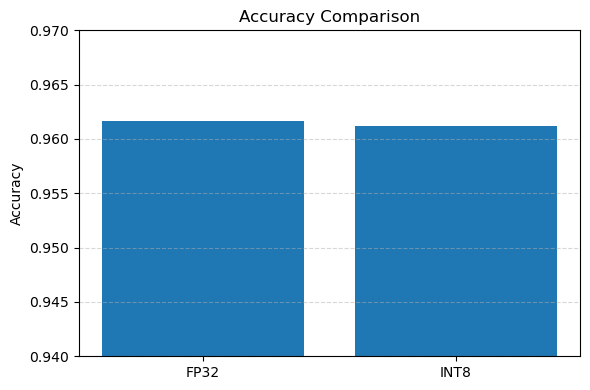

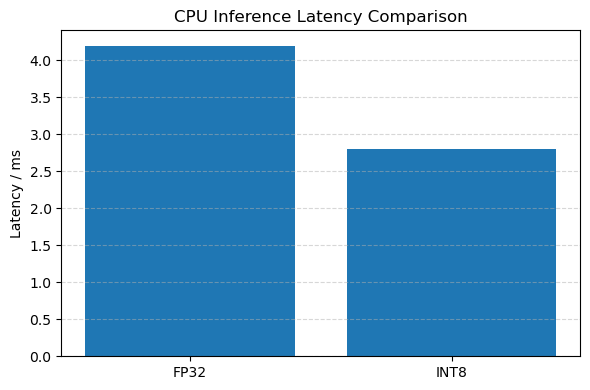

Saved figures:
.\Results_HW4_Notebook\accuracy_comparison.png
.\Results_HW4_Notebook\latency_comparison.png


In [16]:
plt.figure(figsize=(6, 4))
plt.bar(["FP32", "INT8"], [fp32_accuracy, int8_accuracy])
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.ylim(0.94, 0.97)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

acc_fig_path = os.path.join(OUT_DIR, "accuracy_comparison.png")
plt.savefig(acc_fig_path, dpi=300)
plt.show()


plt.figure(figsize=(6, 4))
plt.bar(["FP32", "INT8"], [fp32_latency_ms, int8_latency_ms])
plt.ylabel("Latency / ms")
plt.title("CPU Inference Latency Comparison")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

latency_fig_path = os.path.join(OUT_DIR, "latency_comparison.png")
plt.savefig(latency_fig_path, dpi=300)
plt.show()

print("Saved figures:")
print(acc_fig_path)
print(latency_fig_path)

## 5. 实验结果与分析

### 5.1 总体实验结果

根据上述实验流程，得到量化前后模型的主要指标如下表所示。

| 指标         |   FP32 模型 |   INT8 模型 |        对比结果 |
| ---------- | --------: | --------: | ----------: |
| 测试准确率      |  0.961624 |  0.961240 | 下降 0.000384 |
| 模型大小       | 3.1276 MB | 0.7905 MB | 压缩 3.9564 倍 |
| CPU 单张推理延迟 | 4.1968 ms | 2.8033 ms | 加速 1.4971 倍 |

从表中可以看出，INT8 静态量化后，模型的测试准确率几乎没有下降，但模型大小和 CPU 推理延迟都有明显改善。说明对于本实验中的 SVHN 分类模型，训练后静态量化能够在基本保持分类性能的同时，有效降低模型存储开销，并提升 CPU 推理速度。

### 5.2 精度对比分析

FP32 模型在测试集上的准确率为 0.961624，INT8 模型在测试集上的准确率为 0.961240，量化后的精度损失为 0.000384，约为 0.0384 个百分点。该精度下降非常小，说明模型中的卷积层和全连接层在量化到 INT8 后，虽然参数和激活值的表示精度降低，但整体分类能力基本保持不变。

从精度对比图也可以看出，FP32 和 INT8 两个柱状图高度非常接近，说明静态量化并没有对最终分类准确率造成明显影响。这与 SVHN 任务本身以及模型结构有关：本实验中的 CNN 模型已经具有较好的鲁棒性，而 INT8 量化产生的数值扰动不足以明显改变大多数样本的分类结果。

### 5.3 模型大小对比分析

模型大小方面，FP32 模型大小为 3.1276 MB，INT8 模型大小为 0.7905 MB，压缩比为 3.9564 倍。量化后模型大小约为原来的四分之一，这与 FP32 参数使用 32 bit 表示、INT8 参数使用 8 bit 表示的理论关系基本一致。

这一结果说明，INT8 量化能够显著减少模型存储空间。在嵌入式设备或边缘设备中，存储资源通常比较有限，因此模型压缩是量化方法的重要优势之一。对于本实验中的 CNN 模型，量化后模型大小不足 1 MB，更有利于后续部署到计算和存储资源受限的平台。

### 5.4 推理速度对比分析

在 CPU 单张图片推理延迟测试中，FP32 模型的中位数延迟为 4.1968 ms，INT8 模型的中位数延迟为 2.8033 ms，加速比为 1.4971 倍。可以看出，在当前实验环境下，INT8 模型相比 FP32 模型获得了较明显的推理速度提升。

造成速度提升的主要原因是，量化后卷积层和全连接层中的主要计算由浮点运算变为整数运算，INT8 数据类型的访存开销更小，计算吞吐率更高。同时，本实验使用的量化后端为 onednn，该后端对 CPU 上的 INT8 推理进行了优化，因此量化模型能够在 CPU 上获得一定的加速效果。

需要注意的是，推理速度会受到硬件环境、量化后端、线程数设置、batch size 和计时方式等因素影响。为了减小 Notebook 环境下计时波动，本实验固定 CPU 线程数，并对单张图片进行多轮重复推理，最终取多轮测试的中位数作为延迟结果。从测试结果看，INT8 模型在当前设置下既实现了模型压缩，也取得了推理加速。

### 5.5 逐层量化误差分析

为了进一步分析量化对各层输出的影响，本实验对 FP32 模型和 INT8 模型的部分层输出进行了对比，并计算均方误差 MSE。结果如下表所示。

| 层名称          |      MSE |
| ------------ | -------: |
| features.0   | 0.000171 |
| features.3   | 0.000053 |
| features.8   | 0.000201 |
| features.11  | 0.000255 |
| features.16  | 0.000162 |
| features.19  | 0.000238 |
| classifier.1 | 0.001492 |
| classifier.4 | 0.022537 |

从结果可以看出，前几层卷积层的量化误差整体较小，基本处于 10^-4 量级。这说明卷积特征提取部分在 INT8 量化后仍然能够较好地保持原有输出分布。相比之下，全连接层的误差更大，尤其是最后一层 classifier.4 的 MSE 达到 0.022537，明显高于前面的卷积层。

这种现象说明，随着网络层数加深，前面层产生的量化误差会逐渐传递到后续层，而分类器部分直接影响最终 logits 输出，因此对量化误差更加敏感。不过，从最终准确率来看，虽然最后一层输出存在一定数值误差，但量化后模型的分类准确率仅下降 0.000384，说明这些误差没有显著改变最终分类结果。

## 6. 实验总结

本实验在第二次作业训练得到的 SVHN 分类 CNN 模型基础上，完成了 INT8 静态量化实验。实验首先加载 FP32 基线模型，并测试其准确率、模型大小和 CPU 推理延迟；随后手动实现了线性量化和反量化函数，用于验证 scale 和 zero point 在量化过程中的作用；之后通过插入 QuantStub 和 DeQuantStub、融合 Conv-BatchNorm-ReLU 和 Linear-ReLU 模块、设置 qconfig、使用校准集校准激活值范围，最终将 FP32 模型转换为 INT8 推理模型。

实验结果表明，INT8 静态量化后，模型测试准确率由 0.961624 下降到 0.961240，精度损失仅为 0.000384，说明量化对模型分类性能影响很小。模型大小由 3.1276 MB 减小到 0.7905 MB，压缩比达到 3.9564 倍，体现出明显的模型压缩效果。在 CPU 单张推理延迟方面，FP32 模型延迟为 4.1968 ms，INT8 模型延迟为 2.8033 ms，加速比达到 1.4971 倍，说明量化后模型在当前 CPU 环境下能够获得一定的推理加速。

逐层 MSE 分析表明，卷积层输出的量化误差整体较小，而全连接分类层误差相对更大，说明后部分类层对量化扰动更加敏感。不过最终准确率几乎没有下降，说明这些数值误差仍在模型可接受范围内。

综合来看，INT8 静态量化能够在基本保持模型精度的前提下，显著减小模型大小并提高 CPU 推理效率。对于部署在存储和计算资源受限设备上的图像分类模型，静态量化是一种比较有效的模型压缩和加速方法。后续如果进一步优化，可以尝试 per-channel 权重量化、不同校准集规模、不同量化后端，以及量化感知训练等方法，以进一步降低量化误差并提高模型部署性能。